In [1]:
import yt
import numpy as np
#from yt.mods import *
from yt.frontends.boxlib.api import NyxDataset, AMReXDataset
from yt.data_objects.time_series import DatasetSeries
import matplotlib.pyplot as plt
from matplotlib import rc_context
from matplotlib.animation import FuncAnimation
from IPython import display

In [2]:
from matplotlib.colors import ListedColormap
from matplotlib.colors import LinearSegmentedColormap

colour_list_alt = [[0, 0, 0], [59, 23, 33], [117, 23, 55], [155, 29, 55], [175, 30, 59], [187, 37, 50], [194, 68, 45],#[221, 45, 58], 
                   [207, 76, 47], [215, 88, 45], [219, 96, 47], [233, 107, 48], [242, 129, 61], [253, 147, 71], [253, 160, 65], [255, 181, 119]]
colors = [(e[0] / 255.0, e[1] / 255.0, e[2] / 255.0) for e in colour_list_alt]

nc = len(colors)
c = np.zeros((3, nc, 3))
rgb = ['red', 'green', 'blue']
for idx, e in enumerate(colors):
    for ii in range(3):
        c[ii, idx, :] = [float(idx) / float(nc - 1), e[ii], e[ii]]

cdict = dict(zip(rgb, c))
cmap = LinearSegmentedColormap('sunset', cdict)

In [3]:
class AMReXDatasetSeries(DatasetSeries):
    _dataset_cls = AMReXDataset

In [24]:
location = "../Outputs/Test No Gravity long"
path = location+"/plt?????"
dsLoad = AMReXDatasetSeries(path)

In [25]:
ds = []
for data in dsLoad:
    ds.append(data)

yt : [INFO     ] 2026-09-10 11:30:03,704 Parameters: current_time              = 0.0
yt : [INFO     ] 2026-09-10 11:30:03,705 Parameters: domain_dimensions         = [128 128 128]
yt : [INFO     ] 2026-09-10 11:30:03,705 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-09-10 11:30:03,706 Parameters: domain_right_edge         = [20. 20. 20.]
yt : [INFO     ] 2026-09-10 11:30:03,725 Parameters: current_time              = 25.0000000000002
yt : [INFO     ] 2026-09-10 11:30:03,726 Parameters: domain_dimensions         = [128 128 128]
yt : [INFO     ] 2026-09-10 11:30:03,727 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-09-10 11:30:03,727 Parameters: domain_right_edge         = [20. 20. 20.]
yt : [INFO     ] 2026-09-10 11:30:03,747 Parameters: current_time              = 49.9999999999993
yt : [INFO     ] 2026-09-10 11:30:03,747 Parameters: domain_dimensions         = [128 128 128]
yt : [INFO     ] 2026-09-10 11:30:03,748 Parameters: domain_

In [ ]:
def _relE (field, dat):
    av = dat.ds.all_data().quantities.weighted_average_quantity("Edens", weight = ("index", "ones"))
    return dat["Edens"]/av
for data in ds:
    data.add_field(("boxlib","EdensRel"), function=_relE, sampling_type="local", units="dimensionless",force_override=True)

In [26]:
ds_test = ds[0]
ds_test.field_list

[('boxlib', 'Edens'),
 ('boxlib', 'Edens_pr'),
 ('boxlib', 'Egrad'),
 ('boxlib', 'Ekin'),
 ('boxlib', 'Epot'),
 ('boxlib', 'KGf'),
 ('boxlib', 'KGfVpr'),
 ('boxlib', 'KGfdens'),
 ('boxlib', 'KGfpr'),
 ('boxlib', 'KGfv'),
 ('boxlib', 'PhiGrav'),
 ('boxlib', 'PhiGravV_pr'),
 ('boxlib', 'PhiGrav_pr')]

yt : [INFO     ] 2026-09-10 11:31:37,955 xlim = 0.000000 20.000000
yt : [INFO     ] 2026-09-10 11:31:37,955 ylim = 0.000000 20.000000
yt : [INFO     ] 2026-09-10 11:31:37,957 xlim = 0.000000 20.000000
yt : [INFO     ] 2026-09-10 11:31:37,957 ylim = 0.000000 20.000000
yt : [INFO     ] 2026-09-10 11:31:37,958 Making a fixed resolution buffer of (('boxlib', 'Edens_pr')) 800 by 800



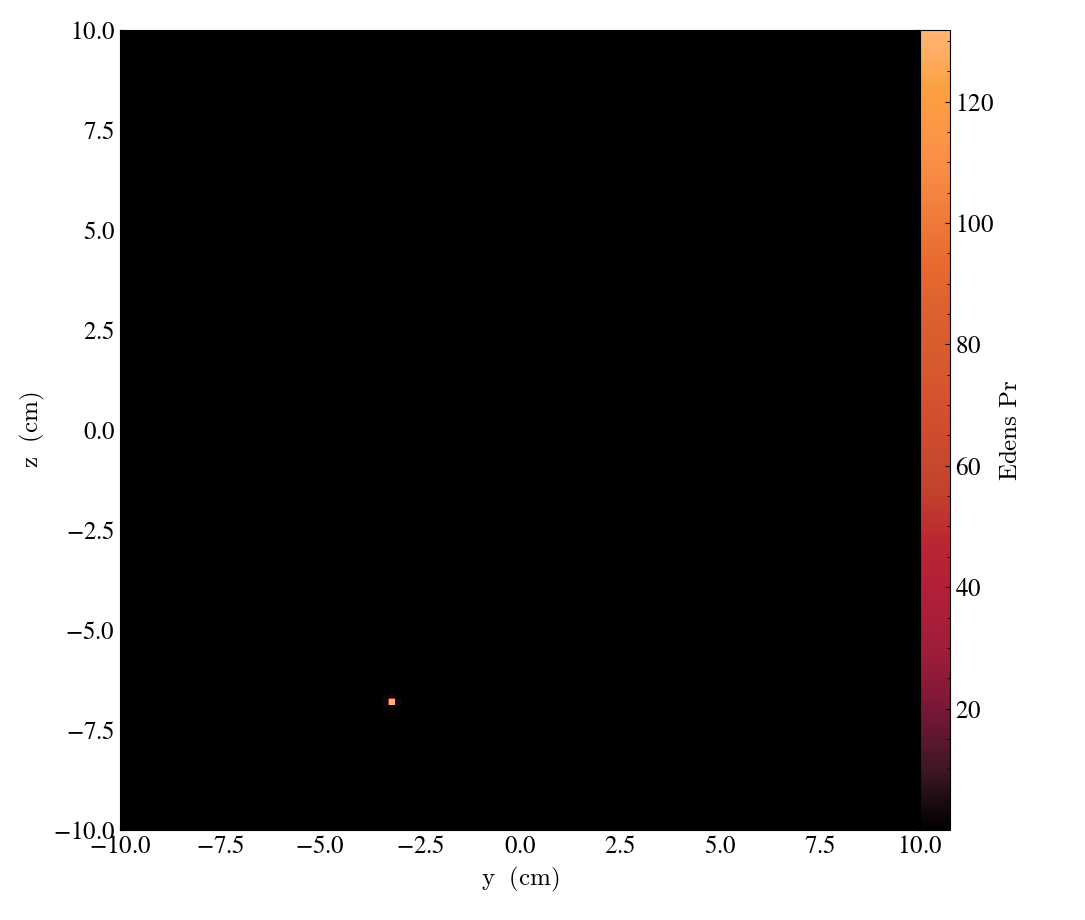

In [35]:
field = "Edens_pr"
plot = yt.SlicePlot(ds[80], "x", field)#, center = [0,0,0])
#plot.set_zlim(("boxlib", "KGfdens"), 1e-13, 2e1)
plot.set_log(field, False)
plot.set_cmap((field), cmap=cmap)
#plot.show()
plot.annotate_grids()

In [36]:
all_data_level_0 = ds[0].covering_grid(level=0, left_edge=[0,0,0],dims=[128,128,128])
print(all_data_level_0["boxlib",field])

[[[0.05522399 0.05522306 0.05522447 ... 0.05522242 0.05522325 0.05522342]
  [0.05522491 0.0552239  0.05522487 ... 0.05522308 0.05522287 0.05522349]
  [0.05522391 0.05522386 0.05522308 ... 0.05522328 0.05522192 0.05522345]
  ...
  [0.05522297 0.05522167 0.05522406 ... 0.05522257 0.05522247 0.05522233]
  [0.05522353 0.0552253  0.05522171 ... 0.05522311 0.05522233 0.0552228 ]
  [0.05522199 0.05522376 0.0552235  ... 0.05522389 0.05522232 0.05522261]]

 [[0.05522392 0.05522267 0.05522424 ... 0.05522368 0.05522284 0.05522388]
  [0.05522434 0.05522415 0.05522431 ... 0.05522319 0.0552245  0.0552223 ]
  [0.05522306 0.05522289 0.05522521 ... 0.05522336 0.05522399 0.05522285]
  ...
  [0.05522414 0.05522288 0.05522286 ... 0.05522317 0.05522303 0.05522203]
  [0.05522212 0.05522216 0.05522257 ... 0.05522394 0.0552227  0.05522253]
  [0.05522394 0.05522274 0.05522259 ... 0.05522235 0.05522207 0.0552226 ]]

 [[0.05522341 0.05522344 0.05522372 ... 0.05522132 0.05522629 0.05522403]
  [0.05522279 0.055224

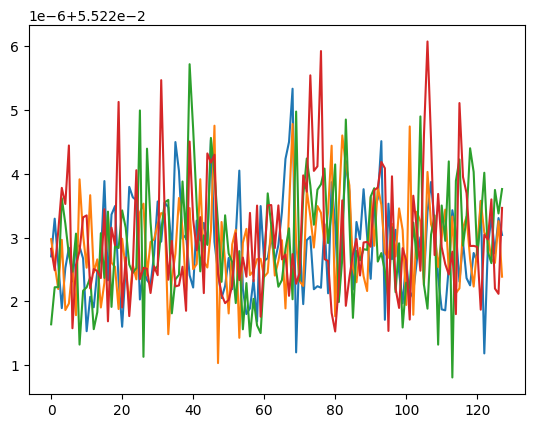

In [37]:
plt.plot(all_data_level_0["boxlib",field][64, 63, :])
plt.plot(all_data_level_0["boxlib",field][64, 64, :])
plt.plot(all_data_level_0["boxlib",field][64, 65, :])
plt.plot(all_data_level_0["boxlib",field][64, 66, :])

In [38]:
fig = plot.plots[("boxlib", field)].figure

In [39]:
def animate(i):
    ts = ds[i]
    plot._switch_ds(ts)

In [40]:
animation = FuncAnimation(fig, animate, frames=len(ds))

In [41]:
# Override matplotlib's defaults to get a nicer looking font
with rc_context({"mathtext.fontset": "stix"}):
    #animation.save("animation.mp4")
    video = animation.to_html5_video()
    html = display.HTML(video)
    display.display(html)

/home/lsou343/.local/lib/python3.10/site-packages/unyt/array.py:1949: RuntimeWarning: invalid value encountered in divide
  out_arr = func(
/home/lsou343/.local/lib/python3.10/site-packages/yt/visualization/image_writer.py:269: RuntimeWarning: invalid value encountered in cast
  mapped = np.dstack([(np.interp(buff, x, v) * 255).astype("uint8") for v in lut])


In [42]:
animation.save(location+f'/animation {field}.mp4',fps=5)

/home/lsou343/.local/lib/python3.10/site-packages/unyt/array.py:1949: RuntimeWarning: invalid value encountered in divide
  out_arr = func(
/home/lsou343/.local/lib/python3.10/site-packages/yt/visualization/image_writer.py:269: RuntimeWarning: invalid value encountered in cast
  mapped = np.dstack([(np.interp(buff, x, v) * 255).astype("uint8") for v in lut])


In [66]:
from matplotlib.animation import PillowWriter
writer = PillowWriter(fps=10,
                                 metadata=dict(artist='Me'),
                                 bitrate=1800)
animation.save(location+f'/animation {field}.gif', writer=writer)


/home/lsou343/.local/lib/python3.10/site-packages/unyt/array.py:1949: RuntimeWarning: invalid value encountered in divide
  out_arr = func(
/home/lsou343/.local/lib/python3.10/site-packages/yt/visualization/image_writer.py:269: RuntimeWarning: invalid value encountered in cast
  mapped = np.dstack([(np.interp(buff, x, v) * 255).astype("uint8") for v in lut])


yt : [INFO     ] 2026-08-10 11:16:19,706 xlim = 0.000000 20.000000
yt : [INFO     ] 2026-08-10 11:16:19,706 ylim = 0.000000 20.000000
yt : [INFO     ] 2026-08-10 11:16:19,709 xlim = 0.000000 20.000000
yt : [INFO     ] 2026-08-10 11:16:19,710 ylim = 0.000000 20.000000
yt : [INFO     ] 2026-08-10 11:16:19,711 Making a fixed resolution buffer of (('boxlib', 'PhiGrav_pr')) 800 by 800
/home/lsou343/.local/lib/python3.10/site-packages/unyt/array.py:1949: RuntimeWarning: invalid value encountered in divide
  out_arr = func(
/home/lsou343/.local/lib/python3.10/site-packages/yt/visualization/image_writer.py:269: RuntimeWarning: invalid value encountered in cast
  mapped = np.dstack([(np.interp(buff, x, v) * 255).astype("uint8") for v in lut])



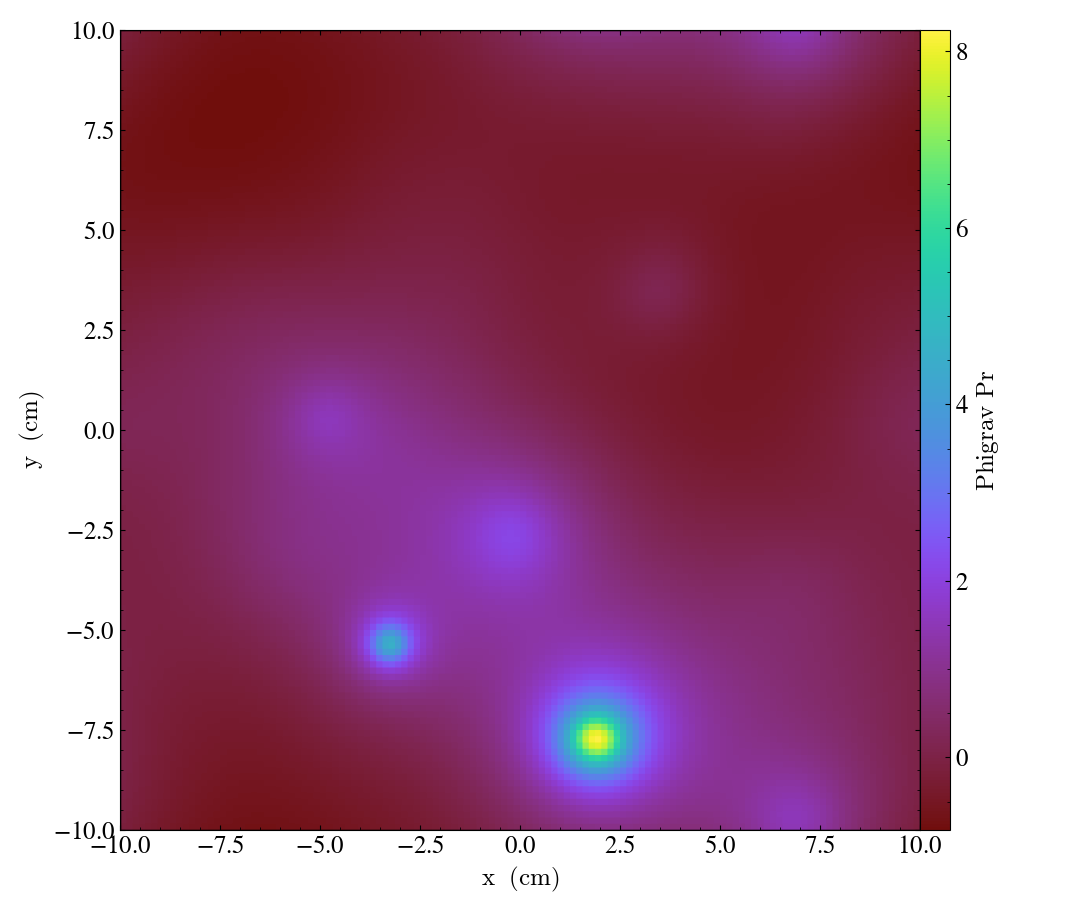

In [31]:
ds_check = ds[-1]

plot = yt.SlicePlot(ds_check, "z", field)#, center = [0,0,0])
#plot.set_zlim(("boxlib", "KGfdens"), 1e-13, 2e1)
plot.set_log(field, False)
#plot.show()
sl = plot.annotate_grids()
sl

In [32]:
sl.save()

yt : [INFO     ] 2026-08-10 11:16:23,526 Saving plot plt09800_Slice_z_PhiGrav_pr.png


['plt09800_Slice_z_PhiGrav_pr.png']

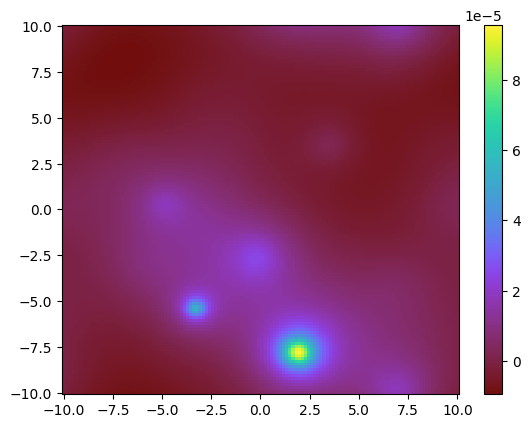

In [38]:
data = ds_check.covering_grid(level=0, left_edge=[0,0,0],dims=[128,128,128])["boxlib", "PhiGrav_pr"]
data = np.array(data)
coef = (6.82239161348826 * 4.300630e+01) ** 2
data /= coef
xs = np.linspace(-10,10,128)
x,y = np.meshgrid(xs,xs,indexing='ij')
plt.pcolormesh(x,y,data[:,:,64], cmap="arbre")
plt.colorbar()
plt.savefig("plt09800_Slice_z_PhiGrav.png",dpi=300)

### Test $\rho$

In [73]:
newt_grad = np.array([3.026388e+00, 5.819476e+00, 6.250378e+01, 3.893255e+02, 1.547635e+03, 4.757839e+03, 1.245846e+04, 2.932945e+04, 6.425342e+04, 1.343138e+05, 2.736203e+05, 5.548838e+05, 
                      1.149668e+06, 2.526604e+06, 6.219892e+06, 1.707285e+07, 2.503389e+07, 1.225490e+08, 7.071238e+17, 3.855895e+80])
newt_kin = np.array([5.901346e+02, 1.441439e+03, 9.894920e+03, 3.441194e+04, 8.680547e+04, 1.866871e+05, 3.672620e+05, 6.872386e+05, 1.256354e+06, 2.294625e+06, 4.284359e+06, 8.412957e+06, 
                     1.809503e+07, 4.538328e+07, 1.448897e+08, 5.786037e+08, 1.355162e+09, 1.056940e+10, 7.561757e+19, 1.190282e+82])
newt_pot = np.array([1.152193e+05, 1.152722e+05, 1.153245e+05, 1.153759e+05, 1.154261e+05, 1.154741e+05, 1.155179e+05, 1.155526e+05, 1.155629e+05, 1.154974e+05, 1.151959e+05, 1.148773e+05, 
                     1.156197e+05, 1.157542e+05, 1.155801e+05, 1.153353e+05, 1.148185e+05, 1.144284e+05, 1.097072e+05, 5.482669e+13])

comov_grad = np.array([3.026388e+00, 2.984676e+00, 2.861957e+00, 2.665291e+00, 2.405958e+00, 2.098802e+00, 1.761356e+00, 1.412822e+00, 1.072951e+00, 7.608960e-01, 4.941048e-01, 2.873195e-01, 
                       1.517353e-01, 9.437253e-02, 1.176970e-01, 2.195072e-01, 3.930968e-01, 6.276788e-01, 9.090460e-01, 1.220427e+00])
comov_kin = np.array([5.901346e+02, 5.907383e+02, 5.921672e+02, 5.936777e+02, 5.952606e+02, 5.969026e+02, 5.985875e+02, 6.002967e+02, 6.020106e+02, 6.037097e+02, 6.053758e+02, 6.069926e+02, 
                      6.085474e+02, 6.100311e+02, 6.114391e+02, 6.127714e+02, 6.140326e+02, 6.152316e+02, 6.163810e+02, 6.174965e+02])
comov_pot = np.array([1.152193e+05, 1.152724e+05, 1.153255e+05, 1.153786e+05, 1.154317e+05, 1.154848e+05, 1.155380e+05, 1.155912e+05, 1.156444e+05, 1.156976e+05, 1.157508e+05, 1.158041e+05, 
                      1.158574e+05, 1.159107e+05, 1.159640e+05, 1.160174e+05, 1.160707e+05, 1.161241e+05, 1.161775e+05, 1.162309e+05])

Text(0.5, 1.0, 'Standard')

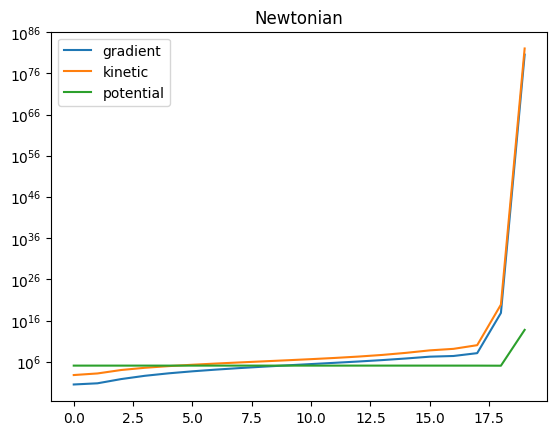

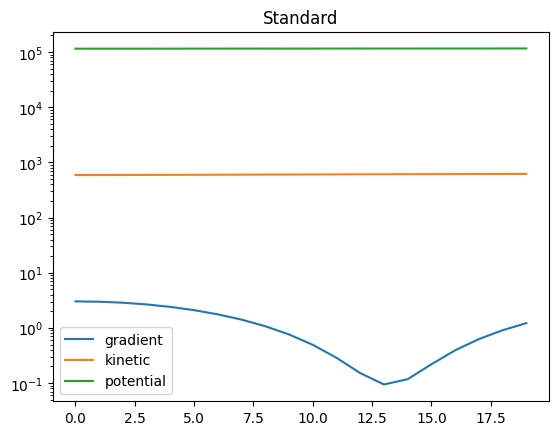

In [74]:
plt.semilogy(newt_grad, label="gradient")
plt.semilogy(newt_kin, label="kinetic")
plt.semilogy(newt_pot, label="potential")
plt.legend()
plt.title("Newtonian")
plt.figure()
plt.semilogy(comov_grad, label="gradient")
plt.semilogy(comov_kin, label="kinetic")
plt.semilogy(comov_pot, label="potential")
plt.legend()
plt.title("Standard")

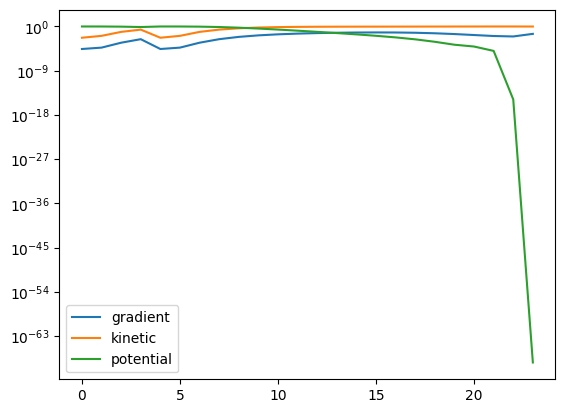

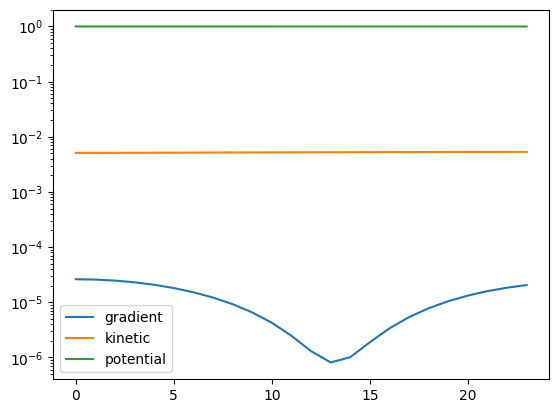

In [67]:
sum = newt_grad + newt_kin + newt_pot
plt.semilogy(newt_grad / sum, label="gradient")
plt.semilogy(newt_kin / sum, label="kinetic")
plt.semilogy(newt_pot / sum, label="potential")
plt.legend()
plt.figure()
sum = comov_grad + comov_kin + comov_pot
plt.semilogy(comov_grad / sum, label="gradient")
plt.semilogy(comov_kin / sum, label="kinetic")
plt.semilogy(comov_pot / sum, label="potential")
plt.legend()

Text(0.5, 1.0, 'Gradient')

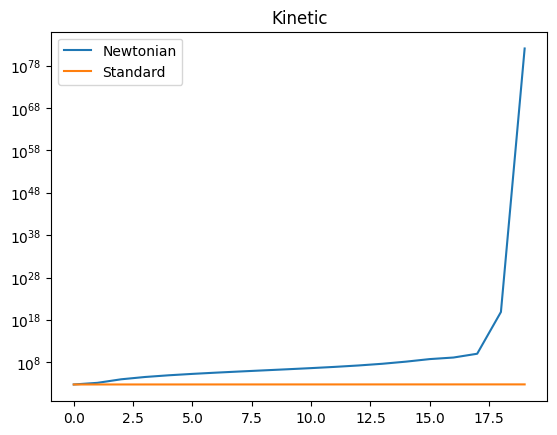

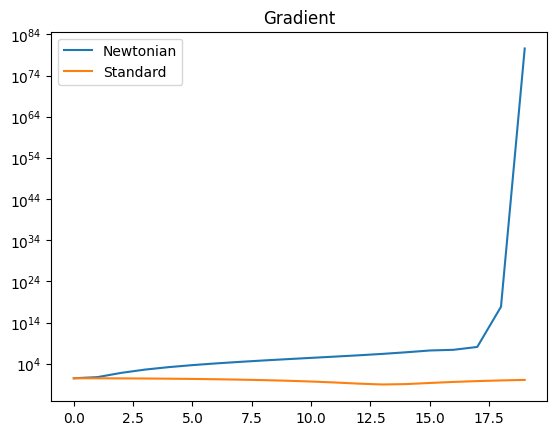

In [79]:
plt.semilogy(newt_kin, label="Newtonian")
plt.semilogy(comov_kin, label="Standard")
plt.legend()
plt.title("Kinetic")
plt.figure()
plt.semilogy(newt_grad, label="Newtonian")
plt.semilogy(comov_grad, label="Standard")
plt.legend()
plt.title("Gradient")

### Initial Conditions

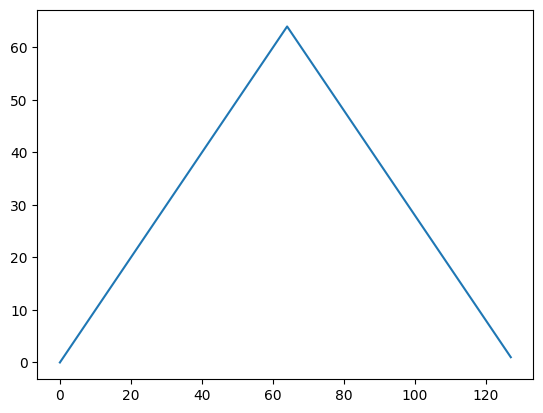

In [24]:
N = 128
ii = []
for i in range(N):
    if i < N / 2:
        ii.append(i)
    else:
        ii.append(N-i)
ii = np.array(ii)
plt.plot(ii)

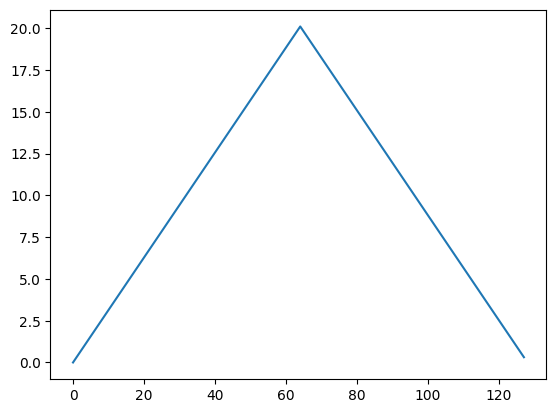

In [32]:
L = 20

omega = (2*np.pi/L) ** 2 * ii ** 2
plt.plot(np.sqrt(omega))

In [44]:
X = np.random.rand(N)
theta1 = 2 * np.pi * np.random.rand(N)
theta2 = 2 * np.pi * np.random.rand(N)

/tmp/ipykernel_1527909/1035922958.py:3: RuntimeWarning: divide by zero encountered in divide
  W2 = (A * B) ** 2 * L ** 3 / (2 * omega * dx ** 6)


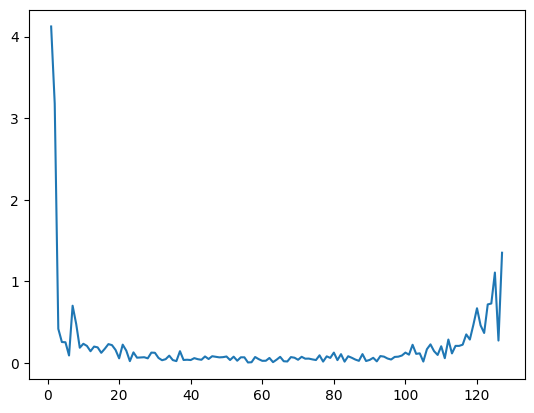

In [43]:
A, B, dx = 43, 1.28e-6, L / N

W2 = (A * B) ** 2 * L ** 3 / (2 * omega * dx ** 6)
fMag = np.sqrt(-1 * W2 * np.log(X))
plt.plot(fMag)

/tmp/ipykernel_1527909/2836335735.py:4: RuntimeWarning: invalid value encountered in multiply
  fdR = (np.sin(theta1) - np.sin(theta2)) * fMag * omega / np.sqrt(2)
/tmp/ipykernel_1527909/2836335735.py:5: RuntimeWarning: invalid value encountered in multiply
  fdI = (np.cos(theta1) - np.cos(theta2)) * fMag * omega / np.sqrt(2)


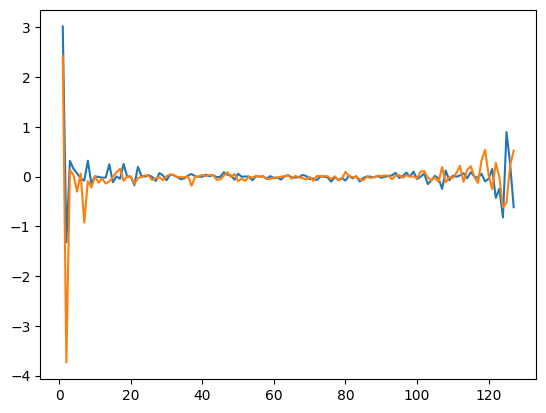

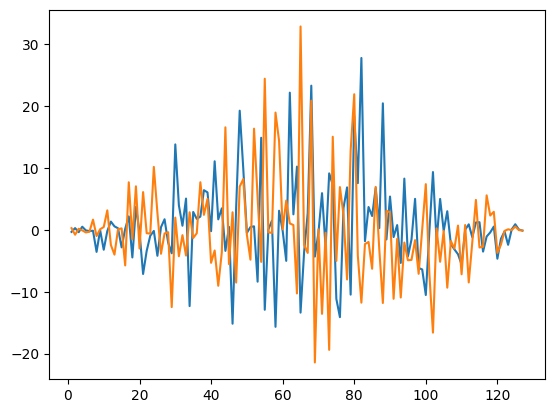

In [45]:
fR = (np.cos(theta1) + np.cos(theta2)) * fMag / np.sqrt(2)
fI = (np.sin(theta1) + np.sin(theta2)) * fMag / np.sqrt(2)

fdR = (np.sin(theta1) - np.sin(theta2)) * fMag * omega / np.sqrt(2)
fdI = (np.cos(theta1) - np.cos(theta2)) * fMag * omega / np.sqrt(2)

plt.plot(fR)
plt.plot(fI)
plt.figure()
plt.plot(fdR)
plt.plot(fdI)

### Differencing stuff

In [50]:
ds1 = AMReXDataset("../Outputs/Test Gravity/plt09000")
ds2 = AMReXDataset("../Outputs/Test No Gravity/plt09000")

yt : [INFO     ] 2026-09-03 15:55:11,059 Parameters: current_time              = 450.000000000068
yt : [INFO     ] 2026-09-03 15:55:11,059 Parameters: domain_dimensions         = [128 128 128]
yt : [INFO     ] 2026-09-03 15:55:11,060 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-09-03 15:55:11,060 Parameters: domain_right_edge         = [20. 20. 20.]
yt : [INFO     ] 2026-09-03 15:55:11,079 Parameters: current_time              = 450.000000000068
yt : [INFO     ] 2026-09-03 15:55:11,080 Parameters: domain_dimensions         = [128 128 128]
yt : [INFO     ] 2026-09-03 15:55:11,081 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-09-03 15:55:11,081 Parameters: domain_right_edge         = [20. 20. 20.]


In [51]:
field = "Edens_pr"

data1 = ds1.covering_grid(level=0, left_edge=[0,0,0],dims=[128,128,128])["boxlib", field]
data2 = ds2.covering_grid(level=0, left_edge=[0,0,0],dims=[128,128,128])["boxlib", field]

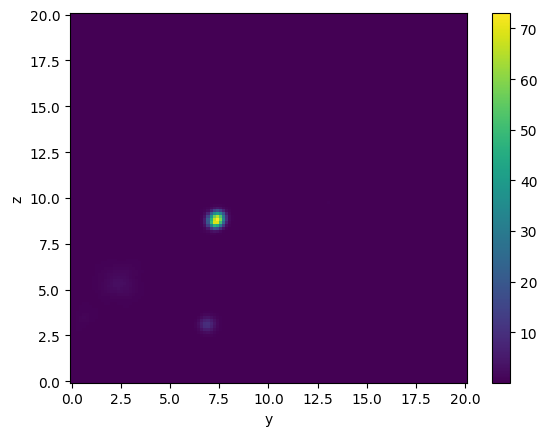

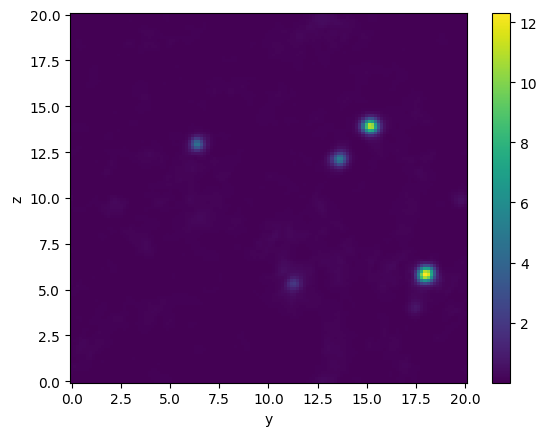

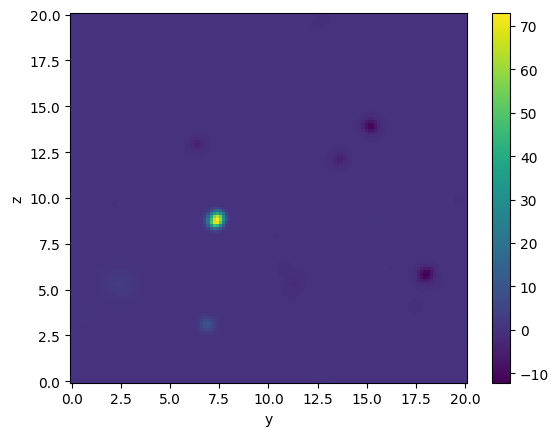

In [52]:
L, N = 20, 128
xs = np.linspace(0, L, N)
x, y = np.meshgrid(xs, xs, indexing='ij')

plt.pcolormesh(x,y,data2[64,:,:])
plt.xlabel("y")
plt.ylabel("z")
plt.colorbar()
plt.figure()
plt.pcolormesh(x,y,data1[64,:,:])
plt.xlabel("y")
plt.ylabel("z")
plt.colorbar()
plt.figure()
plt.pcolormesh(x,y,data2[64,:,:]-data1[64,:,:])
plt.xlabel("y")
plt.ylabel("z")
plt.colorbar()

In [ ]:
L, N = 20, 128
xs = np.linspace(0, L, N)
x, y = np.meshgrid(xs, xs, indexing='ij')


for i in range(0, 10000, 100):
    save_name = str(i)
    while len(save_name) < 5:
        save_name = "0" + save_name

    ds1 = AMReXDataset(f"../Outputs/Test Gravity/plt{save_name}")
    ds2 = AMReXDataset(f"../Outputs/Test No Gravity/plt{save_name}")

    data1 = ds1.covering_grid(level=0, left_edge=[0,0,0],dims=[128,128,128])["boxlib", field]
    data2 = ds2.covering_grid(level=0, left_edge=[0,0,0],dims=[128,128,128])["boxlib", field]

    avg = np.sum(data1 + data2) / (0.5 * 128 ** 3)

    plt.figure()
    plt.pcolormesh(x,y,np.abs(data2[64,:,:]-data1[64,:,:]) / avg)
    plt.xlabel("y")
    plt.ylabel("z")
    plt.colorbar()
    plt.savefig(f"../Outputs/Test Diff/Diff_{save_name}.png", dpi=200)
    plt.close()

yt : [INFO     ] 2026-09-03 15:55:57,199 Parameters: current_time              = 0.0
yt : [INFO     ] 2026-09-03 15:55:57,200 Parameters: domain_dimensions         = [128 128 128]
yt : [INFO     ] 2026-09-03 15:55:57,201 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-09-03 15:55:57,201 Parameters: domain_right_edge         = [20. 20. 20.]
yt : [INFO     ] 2026-09-03 15:55:57,221 Parameters: current_time              = 0.0
yt : [INFO     ] 2026-09-03 15:55:57,221 Parameters: domain_dimensions         = [128 128 128]
yt : [INFO     ] 2026-09-03 15:55:57,222 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-09-03 15:55:57,222 Parameters: domain_right_edge         = [20. 20. 20.]
yt : [INFO     ] 2026-09-03 15:55:57,619 Parameters: current_time              = 4.99999999999999
yt : [INFO     ] 2026-09-03 15:55:57,620 Parameters: domain_dimensions         = [128 128 128]
yt : [INFO     ] 2026-09-03 15:55:57,620 Parameters: domain_left_edge    

In [143]:
ds_alt = AMReXDataset("../Outputs/Test Gravity/plt00000")
data_alt = ds_alt.covering_grid(level=0, left_edge=[0,0,0],dims=[128,128,128])["boxlib", field]
data_alt[0,0,0]

yt : [INFO     ] 2026-09-02 17:00:46,044 Parameters: current_time              = 0.0
yt : [INFO     ] 2026-09-02 17:00:46,044 Parameters: domain_dimensions         = [128 128 128]
yt : [INFO     ] 2026-09-02 17:00:46,044 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-09-02 17:00:46,045 Parameters: domain_right_edge         = [20. 20. 20.]


unyt_quantity(0.99976441, '(dimensionless)')

data1 and data_alt are the same at 0,0,0 but different from data4 and data8 (which are not the same between each other).
* Do we expect them to be different?
* Do we expect data1 and data_alt to be the same?

In [84]:
maxg = 0
maxng = 0

for i in range(0, 10000, 100):
    save_name = str(i)
    while len(save_name) < 5:
        save_name = "0" + save_name

    ds1 = AMReXDataset(f"../Outputs/Test Gravity/plt{save_name}")
    ds2 = AMReXDataset(f"../Outputs/Test No Gravity/plt{save_name}")

    data1 = ds1.covering_grid(level=0, left_edge=[0,0,0],dims=[128,128,128])["boxlib", field]
    data2 = ds2.covering_grid(level=0, left_edge=[0,0,0],dims=[128,128,128])["boxlib", field]
    data1 /= np.mean(data1)
    data2 /= np.mean(data2)
    if np.max(data1) > maxg:
        maxg = np.max(data1)
    if np.max(data2) > maxng:
            maxng = np.max(data2)
print(maxg, maxng)

yt : [INFO     ] 2026-09-03 17:25:05,396 Parameters: current_time              = 0.0
yt : [INFO     ] 2026-09-03 17:25:05,397 Parameters: domain_dimensions         = [128 128 128]
yt : [INFO     ] 2026-09-03 17:25:05,397 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-09-03 17:25:05,398 Parameters: domain_right_edge         = [20. 20. 20.]
yt : [INFO     ] 2026-09-03 17:25:05,418 Parameters: current_time              = 0.0
yt : [INFO     ] 2026-09-03 17:25:05,419 Parameters: domain_dimensions         = [128 128 128]
yt : [INFO     ] 2026-09-03 17:25:05,419 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-09-03 17:25:05,420 Parameters: domain_right_edge         = [20. 20. 20.]
yt : [INFO     ] 2026-09-03 17:25:05,708 Parameters: current_time              = 4.99999999999999
yt : [INFO     ] 2026-09-03 17:25:05,709 Parameters: domain_dimensions         = [128 128 128]
yt : [INFO     ] 2026-09-03 17:25:05,709 Parameters: domain_left_edge    

1807.34595313221 dimensionless 1219.119254220082 dimensionless


In [ ]:
L, N = 20, 128
xs = np.linspace(0, L, N)
x, y = np.meshgrid(xs, xs, indexing='ij')
field = "Edens_pr"

def do_plot(n, data, title):
    #plt.clf()
    plt.subplot(1, 2, n, aspect="equal")
    plt.pcolor(x, y, data, vmin=0, vmax=4)
    plt.title(title)
    plt.colorbar()

plt.figure()
do_plot(1, lambda x:x, "all")
do_plot(2, lambda x:np.clip(x, -4, 0), "<0")
do_plot(3, lambda x:np.clip(x, 0, 4), ">0")
plt.show()

for i in range(0, 10000, 100):
    save_name = str(i)
    while len(save_name) < 5:
        save_name = "0" + save_name

    ds1 = AMReXDataset(f"../Outputs/Test Gravity/plt{save_name}")
    ds2 = AMReXDataset(f"../Outputs/Test No Gravity/plt{save_name}")

    data1 = ds1.covering_grid(level=0, left_edge=[0,0,0],dims=[128,128,128])["boxlib", field]
    data2 = ds2.covering_grid(level=0, left_edge=[0,0,0],dims=[128,128,128])["boxlib", field]

    avg1 = np.sum(data1) / (128 ** 3)
    avg2 = np.sum(data2) / (128 ** 3)

    plt.figure()
    plt.pcolormesh(x,y,np.abs(data1[64,:,:] / avg1))
    plt.pcolormesh(x,y,np.abs(data2[64,:,:] / avg2))
    plt.xlabel("y")
    plt.ylabel("z")
    plt.colorbar()
    plt.savefig(f"../Outputs/Test Diff/Diff_{save_name}.png", dpi=200)
    plt.close()

### Comparisons

In [16]:
L, N = 20, 128
xs = np.linspace(0, L, N)
x, y = np.meshgrid(xs, xs, indexing='ij')
field = "PhiGrav"
max_val = 5e-4
from mpl_toolkits.axes_grid1 import make_axes_locatable

def do_plot(n, data, title):
    #plt.clf()
    plt.subplot(1, 2, n, aspect="equal")
    plt.pcolor(x, y, data, vmin=0, vmax=max_val)
    plt.title(title)
#    plt.xlabel("y")
#    plt.ylabel("z")
#    plt.clim(0,max_val) 

for i in range(0, 50100, 500):
    save_name = str(i)
    while len(save_name) < 5:
        save_name = "0" + save_name

    ds1 = AMReXDataset(f"../Outputs/Test Gravity t=50 long/plt{save_name}")
    ds2 = AMReXDataset(f"../Outputs/Test No Gravity long/plt{save_name}")

    data1 = ds1.covering_grid(level=0, left_edge=[0,0,0],dims=[128,128,128])["boxlib", field]
    data2 = ds2.covering_grid(level=0, left_edge=[0,0,0],dims=[128,128,128])["boxlib", field]

    plt.figure()
#    plt.pcolormesh(x,y,np.abs(data1[64,:,:]))
#    plt.pcolormesh(x,y,np.abs(data2[64,:,:]))
    fig, axes = plt.subplots(1,2,)
    fig.suptitle(f"{field}")
    titles = ["Gravity", "No Gravity"]

    for i, (ax, val) in enumerate(zip(axes.flatten(),[data1[64,:,:],data2[64,:,:]])):
    
        mesh = ax.pcolormesh(x, y, val, vmin=-max_val, vmax=max_val, norm="symlog", cmap="seismic")#"gist_stern")
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size=.08, pad=0.08)
        cbar = fig.colorbar(mesh,cax=cax,)
    
        ax.set_title(titles[i])
        ax.set_aspect('equal')

#    do_plot(1, data1[64,:,:], "Gravity")
#    do_plot(2, data2[64,:,:], "No Gravity")
#    plt.colorbar(orientation='horizontal')

    plt.savefig(f"../Outputs/Test Diff Long/{field}_{save_name}.png", dpi=200)
    plt.close()
print(max_val)

yt : [INFO     ] 2026-09-10 12:27:24,076 Parameters: current_time              = 0.0
yt : [INFO     ] 2026-09-10 12:27:24,076 Parameters: domain_dimensions         = [128 128 128]
yt : [INFO     ] 2026-09-10 12:27:24,077 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-09-10 12:27:24,077 Parameters: domain_right_edge         = [20. 20. 20.]
yt : [INFO     ] 2026-09-10 12:27:24,098 Parameters: current_time              = 0.0
yt : [INFO     ] 2026-09-10 12:27:24,099 Parameters: domain_dimensions         = [128 128 128]
yt : [INFO     ] 2026-09-10 12:27:24,100 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-09-10 12:27:24,100 Parameters: domain_right_edge         = [20. 20. 20.]
yt : [INFO     ] 2026-09-10 12:27:24,528 Parameters: current_time              = 25.0000000000002
yt : [INFO     ] 2026-09-10 12:27:24,528 Parameters: domain_dimensions         = [128 128 128]
yt : [INFO     ] 2026-09-10 12:27:24,529 Parameters: domain_left_edge    

0.0005


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [ ]:
L = np.linspace(0, data.domain_width_pr[0], data.domain_dimensions[0])
N = data.domain_dimensions[0]
N2 = int(N/2)
x0,y0=np.meshgrid(L,L,indexing='ij')

vals = [phi[N2,:,:] / (A * data.a[timeslice] ** r), phip[N2,:,:] * B * data.a[timeslice] ** s, edens[N2,:,:]/ edens.mean(), pressure[N2,:,:]/ np.abs(pressure.mean())]
titles = [r'$\phi$', r'$\dot{\phi}$', r'$\rho / \langle \rho \rangle$', r'$p/ | \langle p \rangle |$']

fig, axes = plt.subplots(2,2,tight_layout=True,)

for i, (ax, val) in enumerate(zip(axes.flatten(),vals)):
    
    mesh = ax.pcolormesh(x0, y0, val)
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size=.08, pad=0.08)
    cbar = fig.colorbar(mesh,cax=cax,)
    
#     if False:
# #     if i in [0,1]:
# #         peak = [val.min(), val.max()]
#         peak = val.min() if abs(val.min())>val.max() else val.max()
#         ax.contour(val,[peak/(3*np.exp(1))],colors='g')
#     if True:
#         peak = Edens_cr.max()
#         ax.contour(vals[2],[peak/(6*np.exp(1))],colors='b')
    
    ax.set_title(titles[i])
    ax.set_aspect('equal')
#fig.savefig(os.path.join(output_dir,f'TMI 512.png'),dpi=300,facecolor='w',bbox_inches='tight',)